# Data Exploration

This notebook provides exploratory analysis of the CanESM5 climate data:
1. Surface temperature (tas) patterns and trends
2. TOA radiation budget (rsdt, rsut, rlut)
3. Cloud Radiative Effects (CRE)
4. Temporal and spatial patterns

In [7]:
import sys
sys.path.append('..')

from utils import (
    load_dataset,
    plot_spatial_map,
    plot_time_series,
    plot_zonal_mean
)

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import nc_time_axis

## 1. Surface Temperature (tas) Analysis

In [3]:
# Load surface temperature data
tas_ds = load_dataset("../../data/CanESM5_historical_tas.nc")
tas = tas_ds["tas"]

print("Dataset overview:")
print(tas_ds)
print("\nDimensions:", tas_ds.dims)
print("Coordinates:", list(tas_ds.coords))
print("Data variables:", list(tas_ds.data_vars))

Dataset overview:
<xarray.Dataset> Size: 2GB
Dimensions:    (member: 25, time: 1980, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * member     (member) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (member, time, bnds) object 792kB ...
    lat_bnds   (member, lat, bnds) float64 26kB ...
    lon_bnds   (member, lon, bnds) float64 51kB ...
    tas        (member, time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CCCma_model_hash:            8ac7a3c953a92eb65289508ded4d1b280d2bae9e
    CCCma_parent_runid:          p2-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 p2-his01
    Convention

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

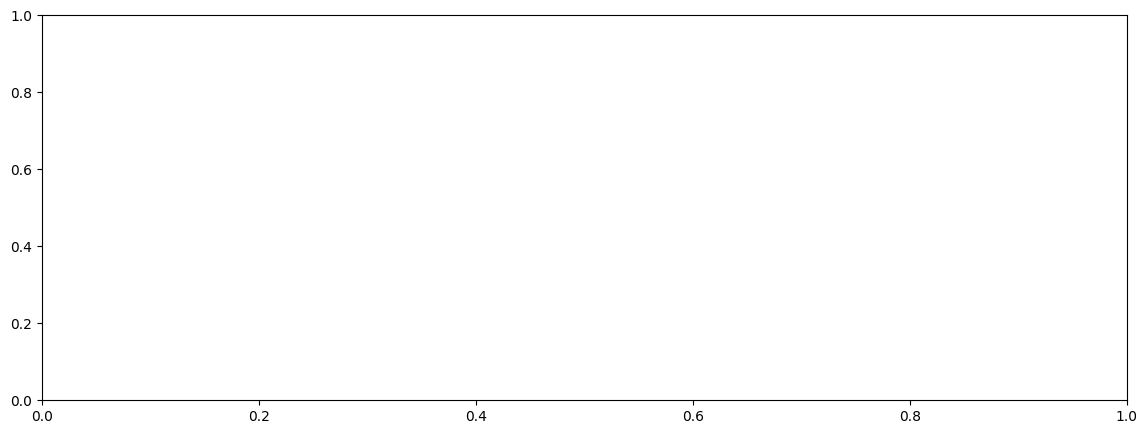

In [8]:
# Plot global mean time series
plot_time_series(
    tas,
    title="Global Mean Surface Temperature (CanESM5 Historical)",
    ylabel="Temperature (K)",
    add_smoothed=True,
    window=120  # 10-year rolling mean
)
plt.show()

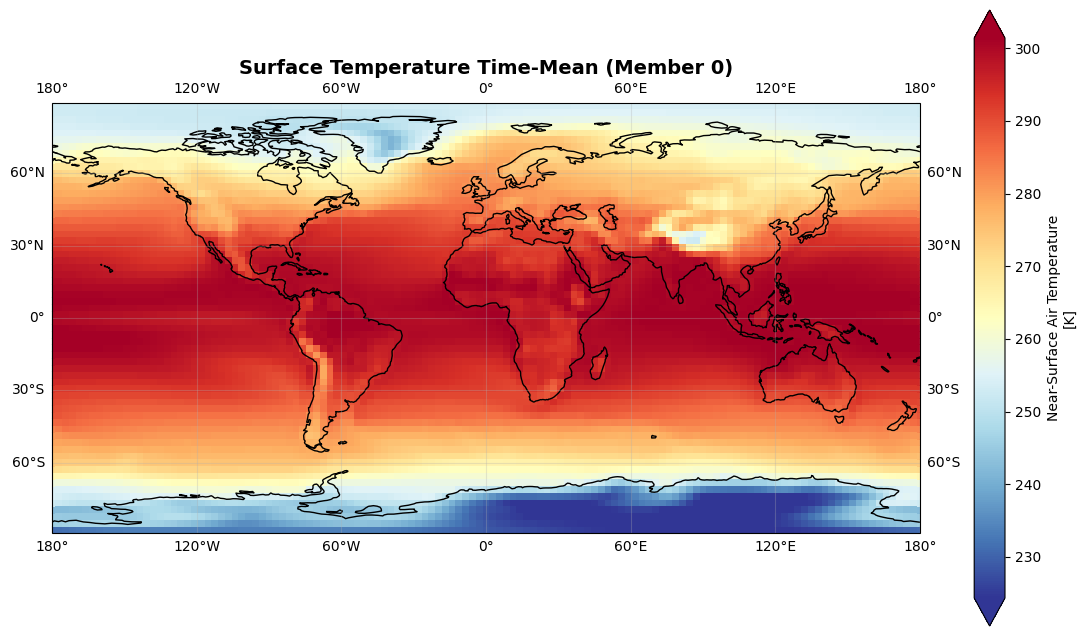

In [9]:
# Plot spatial pattern (time-mean)
plot_spatial_map(
    tas,
    title="Surface Temperature Time-Mean (Member 0)",
    cmap="RdYlBu_r"
)
plt.show()

## 2. TOA Radiation Budget

Analyze the Top-of-Atmosphere radiation balance:
- **rsdt**: Incoming solar radiation
- **rsut**: Outgoing reflected solar radiation  
- **rlut**: Outgoing thermal radiation
- **Net TOA**: rsdt - rsut - rlut

In [ ]:
# Load TOA radiation components
rsdt = load_dataset("../../data/CanESM5_hist_rsdt.nc")["rsdt"]
rsut = load_dataset("../../data/CanESM5_hist_rsut.nc")["rsut"]
rlut = load_dataset("../../data/CanESM5_hist_rlut.nc")["rlut"]

# Align datasets
rsdt, rsut, rlut = xr.align(rsdt, rsut, rlut)

# Compute net TOA radiation
net_toa = rsdt - rsut - rlut
net_toa.attrs['long_name'] = 'Net TOA Radiation'
net_toa.attrs['units'] = 'W/m^2'

print("Net TOA radiation computed")
print(net_toa)

In [ ]:
# Plot global mean net TOA with trend
global_mean = net_toa.mean(dim=["lat", "lon"])
if "member" in global_mean.dims:
    global_mean = global_mean.mean(dim="member")

years = global_mean["time"].dt.year + (global_mean["time"].dt.month - 1) / 12

# Compute linear trend
coeffs = np.polyfit(years, global_mean.values, 1)
trend_line = np.polyval(coeffs, years)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
global_mean.plot(ax=ax, label="Monthly")

# Rolling mean
global_mean_smooth = global_mean.rolling(time=120, center=True).mean()
global_mean_smooth.plot(ax=ax, color="red", linewidth=2, label="10-year rolling mean")

ax.set_title("Global Mean Net TOA Radiation", fontsize=14, fontweight="bold")
ax.set_ylabel("W/m²", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trend: {coeffs[0]:.5f} W/m² per year")

In [ ]:
# Plot zonal mean evolution
plot_zonal_mean(
    net_toa,
    title="Zonal Mean Net TOA Flux Evolution"
)
plt.show()

In [ ]:
# Plot spatial pattern
plot_spatial_map(
    net_toa,
    title="Net TOA Radiation (Time-Mean)",
    cmap="viridis"
)
plt.show()

## 3. Cloud Radiative Effects

Explore the impact of clouds on radiation budget.

In [ ]:
# Load CRE data (if already computed)
try:
    swcre = load_dataset("../../data/CanESM5_1850-2100_rsutcre.nc")["cre"]
    lwcre = load_dataset("../../data/CanESM5_1850-2100_rlutcre.nc")["cre"]
    
    # Plot both CREs side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), 
                                    subplot_kw={'projection': plt.gcf().canvas.manager.pyplot.gcf()})
    
    plot_spatial_map(swcre, title="Shortwave CRE", vmin=-60, vmax=60, ax=ax1)
    plot_spatial_map(lwcre, title="Longwave CRE", vmin=-60, vmax=60, ax=ax2)
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("CRE data not found. Run 01_data_preparation.ipynb first.")

In [ ]:
# Plot time series comparison
try:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    plot_time_series(
        swcre.isel(time=slice(0, 300)),
        title="Shortwave CRE (First 300 months)",
        ylabel="W/m²",
        ax=ax1
    )
    
    plot_time_series(
        lwcre.isel(time=slice(0, 300)),
        title="Longwave CRE (First 300 months)",
        ylabel="W/m²",
        ax=ax2
    )
    
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("CRE data not loaded")

## Summary

Key findings:
- Surface temperature shows warming trend over historical period
- Net TOA radiation shows energy imbalance evolution
- Cloud radiative effects show distinct spatial patterns:
  - Shortwave CRE: clouds reflect more solar radiation (cooling effect)
  - Longwave CRE: clouds trap more thermal radiation (warming effect)